In [8]:
# Importing all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

print("All libraries imported successfully!")

All libraries imported successfully!


In [27]:
# Loading train, validation and test splits
X_train_df = pd.read_csv("Activity_PCA99_Train.csv")
X_val_df   = pd.read_csv("Activity_PCA99_Validation.csv")
X_test_df  = pd.read_csv("Activity_PCA99_Test.csv")

X_train = X_train_df.drop(columns=["Activity"])
y_train = X_train_df["Activity"]

X_val   = X_val_df.drop(columns=["Activity"])
y_val   = X_val_df["Activity"]

X_test  = X_test_df.drop(columns=["Activity"])
y_test  = X_test_df["Activity"]

print("Dataset loaded successfully!")
print(f"Train size     : {X_train.shape}")
print(f"Validation size: {X_val.shape}")
print(f"Test size      : {X_test.shape}")
print(f"\nClasses: {y_train.unique()}")

Dataset loaded successfully!
Train size     : (6179, 156)
Validation size: (2060, 156)
Test size      : (2060, 156)

Classes: ['WALKING_UPSTAIRS' 'WALKING' 'SITTING' 'LAYING' 'WALKING_DOWNSTAIRS'
 'STANDING']


In [28]:
def print_metrics(y_true, y_pred, dataset_name="Test"):
    """
    Prints confusion matrix and classification metrics
    for multiclass classification.
    """
    cm       = confusion_matrix(y_true, y_pred)
    acc      = accuracy_score(y_true, y_pred)
    prec_mac = precision_score(y_true, y_pred, average='macro',  zero_division=0)
    prec_mic = precision_score(y_true, y_pred, average='micro',  zero_division=0)
    rec_mac  = recall_score(y_true, y_pred,    average='macro',  zero_division=0)
    rec_mic  = recall_score(y_true, y_pred,    average='micro',  zero_division=0)
    f1_mac   = f1_score(y_true, y_pred,        average='macro',  zero_division=0)
    f1_mic   = f1_score(y_true, y_pred,        average='micro',  zero_division=0)

    print(f"\n{'='*50}")
    print(f"  {dataset_name} Results")
    print(f"{'='*50}")
    print("Confusion Matrix:")
    print(cm)
    print(f"\nAccuracy          : {acc:.4f}")
    print(f"Precision (Macro) : {prec_mac:.4f}")
    print(f"Precision (Micro) : {prec_mic:.4f}")
    print(f"Recall    (Macro) : {rec_mac:.4f}")
    print(f"Recall    (Micro) : {rec_mic:.4f}")
    print(f"F1-Score  (Macro) : {f1_mac:.4f}")
    print(f"F1-Score  (Micro) : {f1_mic:.4f}")

    return acc

print("Helper function defined!")

Helper function defined!


In [29]:
print("Training Logistic Regression on PCA 99% variance data...")

logistic_reg = LogisticRegression(solver='liblinear', max_iter=1000)
logistic_reg.fit(X_train, y_train)

print("Done!")

y_val_pred_lr  = logistic_reg.predict(X_val)
y_test_pred_lr = logistic_reg.predict(X_test)

Training Logistic Regression on PCA 99% variance data...
Done!


In [30]:
print("=" * 55)
print("TASK 4.1: LOGISTIC REGRESSION - PCA 99% VARIANCE")
print("=" * 55)

acc_lr_val  = print_metrics(y_val, y_val_pred_lr, "Validation")
acc_lr_test = print_metrics(y_test, y_test_pred_lr, "Test")

TASK 4.1: LOGISTIC REGRESSION - PCA 99% VARIANCE

  Validation Results
Confusion Matrix:
[[389   0   0   0   0   0]
 [  0 333  21   0   0   1]
 [  0  15 366   0   0   0]
 [  0   0   0 344   1   0]
 [  0   0   0   1 280   0]
 [  0   0   0   1   1 307]]

Accuracy          : 0.9801
Precision (Macro) : 0.9811
Precision (Micro) : 0.9801
Recall    (Macro) : 0.9810
Recall    (Micro) : 0.9801
F1-Score  (Macro) : 0.9810
F1-Score  (Micro) : 0.9801

  Test Results
Confusion Matrix:
[[389   0   0   0   0   0]
 [  0 343  13   0   0   0]
 [  0  20 361   0   0   0]
 [  0   0   0 342   1   1]
 [  0   0   0   0 280   1]
 [  0   0   0   4   0 305]]

Accuracy          : 0.9806
Precision (Macro) : 0.9814
Precision (Micro) : 0.9806
Recall    (Macro) : 0.9814
Recall    (Micro) : 0.9806
F1-Score  (Macro) : 0.9814
F1-Score  (Micro) : 0.9806


In [31]:
print("Training SVM Linear on PCA 99% variance data... (may take a few minutes)")

linear_svm = SVC(kernel='linear', C=1.0)
linear_svm.fit(X_train, y_train)

print("Done!")

y_val_pred_lin  = linear_svm.predict(X_val)
y_test_pred_lin = linear_svm.predict(X_test)

Training SVM Linear on PCA 99% variance data... (may take a few minutes)
Done!


In [32]:
print("=" * 55)
print("TASK 4.2: SVM (LINEAR KERNEL) - PCA 99% VARIANCE")
print("=" * 55)

acc_lin_val  = print_metrics(y_val, y_val_pred_lin, "Validation")
acc_lin_test = print_metrics(y_test, y_test_pred_lin, "Test")

TASK 4.2: SVM (LINEAR KERNEL) - PCA 99% VARIANCE

  Validation Results
Confusion Matrix:
[[389   0   0   0   0   0]
 [  0 336  18   0   0   1]
 [  0  22 359   0   0   0]
 [  0   0   0 345   0   0]
 [  0   0   0   1 280   0]
 [  0   0   0   0   0 309]]

Accuracy          : 0.9796
Precision (Macro) : 0.9808
Precision (Micro) : 0.9796
Recall    (Macro) : 0.9809
Recall    (Micro) : 0.9796
F1-Score  (Macro) : 0.9808
F1-Score  (Micro) : 0.9796

  Test Results
Confusion Matrix:
[[389   0   0   0   0   0]
 [  0 344  12   0   0   0]
 [  0  18 363   0   0   0]
 [  0   0   0 344   0   0]
 [  0   0   0   0 281   0]
 [  0   0   0   3   0 306]]

Accuracy          : 0.9840
Precision (Macro) : 0.9849
Precision (Micro) : 0.9840
Recall    (Macro) : 0.9849
Recall    (Micro) : 0.9840
F1-Score  (Macro) : 0.9849
F1-Score  (Micro) : 0.9840


In [33]:
print("Training Polynomial SVM for degrees 2, 3, 4, 5 on PCA 99% variance data...")
print("(Please wait)\n")

best_degree  = None
best_val_acc = 0
degree_val_accuracies = {}

for degree in [2, 3, 4, 5]:
    poly_svm = SVC(kernel='poly', degree=degree, C=1.0, gamma='scale')
    poly_svm.fit(X_train, y_train)
    
    val_acc = poly_svm.score(X_val, y_val)
    degree_val_accuracies[degree] = val_acc
    print(f"Degree={degree}, Validation Accuracy={val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_degree  = degree

print(f"\nBest Degree: {best_degree} with Validation Accuracy: {best_val_acc:.4f}")

Training Polynomial SVM for degrees 2, 3, 4, 5 on PCA 99% variance data...
(Please wait)

Degree=2, Validation Accuracy=0.9801
Degree=3, Validation Accuracy=0.9748
Degree=4, Validation Accuracy=0.9592
Degree=5, Validation Accuracy=0.9490

Best Degree: 2 with Validation Accuracy: 0.9801


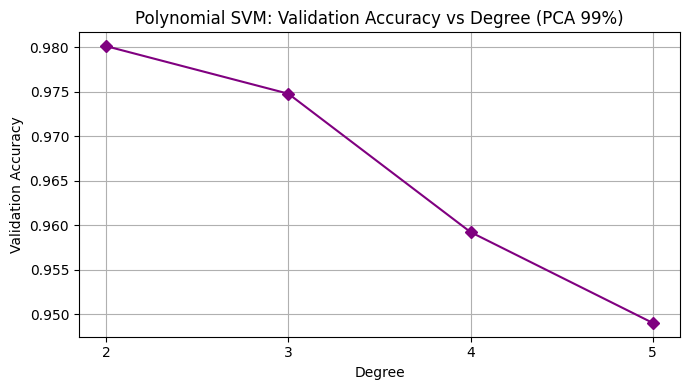

In [34]:
plt.figure(figsize=(7, 4))
plt.plot(list(degree_val_accuracies.keys()), list(degree_val_accuracies.values()), marker='D', color='purple')
plt.title('Polynomial SVM: Validation Accuracy vs Degree (PCA 99%)')
plt.xlabel('Degree')
plt.ylabel('Validation Accuracy')
plt.xticks([2, 3, 4, 5])
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
print(f"Training final model with best degree = {best_degree}...")

best_poly_svm = SVC(kernel='poly', degree=best_degree, C=1.0, gamma='scale')
best_poly_svm.fit(X_train, y_train)

y_val_pred_poly  = best_poly_svm.predict(X_val)
y_test_pred_poly = best_poly_svm.predict(X_test)

print("Done!")

Training final model with best degree = 2...
Done!


In [36]:
print("=" * 60)
print(f"TASK 3.3: SVM (POLY KERNEL, DEGREE={best_degree}) - PCA 99% VARIANCE")
print("=" * 60)

print("\nValidation Accuracies for all degrees:")
for d, acc in degree_val_accuracies.items():
    marker = " <-- best" if d == best_degree else ""
    print(f"  Degree {d}: {acc:.4f}{marker}")

acc_poly_val  = print_metrics(y_val, y_val_pred_poly, "Validation (Best Degree)")
acc_poly_test = print_metrics(y_test, y_test_pred_poly, "Test (Best Degree)")

TASK 3.3: SVM (POLY KERNEL, DEGREE=2) - PCA 99% VARIANCE

Validation Accuracies for all degrees:
  Degree 2: 0.9801 <-- best
  Degree 3: 0.9748
  Degree 4: 0.9592
  Degree 5: 0.9490

  Validation (Best Degree) Results
Confusion Matrix:
[[388   1   0   0   0   0]
 [  0 334  20   0   0   1]
 [  0  15 366   0   0   0]
 [  0   0   0 345   0   0]
 [  0   0   0   1 278   2]
 [  0   0   0   1   0 308]]

Accuracy          : 0.9801
Precision (Macro) : 0.9812
Precision (Micro) : 0.9801
Recall    (Macro) : 0.9808
Recall    (Micro) : 0.9801
F1-Score  (Macro) : 0.9810
F1-Score  (Micro) : 0.9801

  Test (Best Degree) Results
Confusion Matrix:
[[388   0   1   0   0   0]
 [  0 340  16   0   0   0]
 [  0  14 367   0   0   0]
 [  0   0   0 343   0   1]
 [  0   0   0   0 278   3]
 [  0   0   0   1   1 307]]

Accuracy          : 0.9820
Precision (Macro) : 0.9828
Precision (Micro) : 0.9820
Recall    (Macro) : 0.9826
Recall    (Micro) : 0.9820
F1-Score  (Macro) : 0.9827
F1-Score  (Micro) : 0.9820


In [37]:
# Task 1.4 - SVM with RBF Kernel
print("Training SVM with RBF Kernel on PCA 99% variance data...")

rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale')
rbf_svm.fit(X_train, y_train)

print("Done!")

y_val_pred_rbf  = rbf_svm.predict(X_val)
y_test_pred_rbf = rbf_svm.predict(X_test)

Training SVM with RBF Kernel on PCA 99% variance data...
Done!


In [38]:
print("=" * 55)
print("TASK 4.4: SVM (RBF KERNEL) - PCA 99% VARIANCE")
print("=" * 55)

acc_rbf_val  = print_metrics(y_val, y_val_pred_rbf, "Validation")
acc_rbf_test = print_metrics(y_test, y_test_pred_rbf, "Test")

TASK 4.4: SVM (RBF KERNEL) - PCA 99% VARIANCE

  Validation Results
Confusion Matrix:
[[389   0   0   0   0   0]
 [  0 336  18   0   0   1]
 [  0  16 365   0   0   0]
 [  0   0   0 345   0   0]
 [  0   0   0   1 280   0]
 [  0   0   0   0   0 309]]

Accuracy          : 0.9825
Precision (Macro) : 0.9836
Precision (Micro) : 0.9825
Recall    (Macro) : 0.9835
Recall    (Micro) : 0.9825
F1-Score  (Macro) : 0.9835
F1-Score  (Micro) : 0.9825

  Test Results
Confusion Matrix:
[[389   0   0   0   0   0]
 [  0 344  12   0   0   0]
 [  0  16 365   0   0   0]
 [  0   0   0 344   0   0]
 [  0   0   0   0 280   1]
 [  0   0   0   2   0 307]]

Accuracy          : 0.9850
Precision (Macro) : 0.9858
Precision (Micro) : 0.9850
Recall    (Macro) : 0.9857
Recall    (Micro) : 0.9850
F1-Score  (Macro) : 0.9857
F1-Score  (Micro) : 0.9850


In [39]:
comparison_val = {
    'Classifier':          ['Logistic Regression', 'SVM Linear', f'SVM Poly (d={best_degree})', 'SVM RBF'],
    'Validation Accuracy': [acc_lr_val, acc_lin_val, acc_poly_val, acc_rbf_val]
}

comparison_test = {
    'Classifier':    ['Logistic Regression', 'SVM Linear', f'SVM Poly (d={best_degree})', 'SVM RBF'],
    'Test Accuracy': [acc_lr_test, acc_lin_test, acc_poly_test, acc_rbf_test]
}

df_val  = pd.DataFrame(comparison_val)
df_test = pd.DataFrame(comparison_test)

print("Validation Accuracy Comparison (PCA 99% Variance):")
print(df_val.to_string(index=False))

print("\nTest Accuracy Comparison (PCA 99% Variance):")
print(df_test.to_string(index=False))

Validation Accuracy Comparison (PCA 99% Variance):
         Classifier  Validation Accuracy
Logistic Regression             0.980097
         SVM Linear             0.979612
     SVM Poly (d=2)             0.980097
            SVM RBF             0.982524

Test Accuracy Comparison (PCA 99% Variance):
         Classifier  Test Accuracy
Logistic Regression       0.980583
         SVM Linear       0.983981
     SVM Poly (d=2)       0.982039
            SVM RBF       0.984951


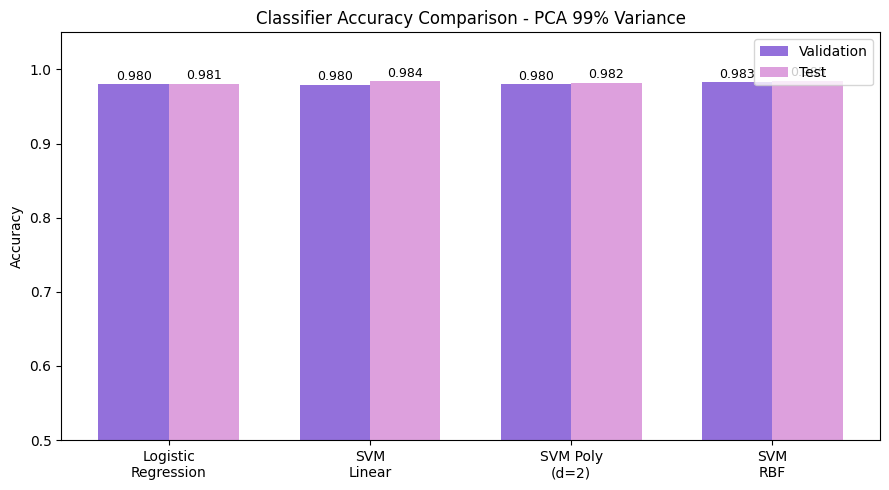


Discussion:
Best classifier on Validation: SVM RBF (0.9825)
Best classifier on Test:       SVM RBF (0.9850)


In [40]:
classifiers = ['Logistic\nRegression', 'SVM\nLinear', f'SVM Poly\n(d={best_degree})', 'SVM\nRBF']
val_accs  = [acc_lr_val, acc_lin_val, acc_poly_val, acc_rbf_val]
test_accs = [acc_lr_test, acc_lin_test, acc_poly_test, acc_rbf_test]

x = np.arange(len(classifiers))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, val_accs,  width, label='Validation', color='mediumpurple')
bars2 = ax.bar(x + width/2, test_accs, width, label='Test', color='plum')

ax.set_title('Classifier Accuracy Comparison - PCA 99% Variance')
ax.set_ylabel('Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(classifiers)
ax.legend()
ax.set_ylim(0.5, 1.05)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

best_val_clf  = classifiers[np.argmax(val_accs)].replace('\n', ' ')
best_test_clf = classifiers[np.argmax(test_accs)].replace('\n', ' ')
print(f"\nDiscussion:")
print(f"Best classifier on Validation: {best_val_clf} ({max(val_accs):.4f})")
print(f"Best classifier on Test:       {best_test_clf} ({max(test_accs):.4f})")

In [41]:

# --- Original Data ---
acc_lr_orig_val    = 0.985437  
acc_lin_orig_val   = 0.981553
acc_poly_orig_val  = 0.986408
acc_rbf_orig_val   = 0.967476

acc_lr_orig_test   = 0.983981
acc_lin_orig_test  = 0.984466
acc_poly_orig_test = 0.987864
acc_rbf_orig_test  = 0.974757

# --- Scaled Data ---
acc_lr_scaled_val    = 0.983010  
acc_lin_scaled_val   = 0.979612
acc_poly_scaled_val  = 0.973786
acc_rbf_scaled_val   = 0.977184

acc_lr_scaled_test   = 0.983010
acc_lin_scaled_test  = 0.984951
acc_poly_scaled_test = 0.975243
acc_rbf_scaled_test  = 0.981068

# --- PCA All Components ---
acc_lr_pcaall_val    = 0.985437 
acc_lin_pcaall_val   = 0.981553
acc_poly_pcaall_val  = 0.981068
acc_rbf_pcaall_val   = 0.983495

acc_lr_pcaall_test   = 0.984466
acc_lin_pcaall_test  = 0.984466
acc_poly_pcaall_test = 0.983010
acc_rbf_pcaall_test  = 0.986408

# --- PCA 99% Variance ---
acc_lr_pca99_val    = acc_lr_val
acc_lin_pca99_val   = acc_lin_val
acc_poly_pca99_val  = acc_poly_val
acc_rbf_pca99_val   = acc_rbf_val

acc_lr_pca99_test   = acc_lr_test
acc_lin_pca99_test  = acc_lin_test
acc_poly_pca99_test = acc_poly_test
acc_rbf_pca99_test  = acc_rbf_test

print("Values loaded!")

Values loaded!


In [42]:
# Overall Validation Accuracy Comparison Table
data_val = {
    "Dataset":            ["Original", "Scaled", "PCA All", "PCA 99"],
    "Logistic Regression": [acc_lr_orig_val,   acc_lr_scaled_val,   acc_lr_pcaall_val,   acc_lr_pca99_val],
    "SVM Linear":          [acc_lin_orig_val,  acc_lin_scaled_val,  acc_lin_pcaall_val,  acc_lin_pca99_val],
    "SVM Polynomial":      [acc_poly_orig_val, acc_poly_scaled_val, acc_poly_pcaall_val, acc_poly_pca99_val],
    "SVM Gaussian":        [acc_rbf_orig_val,  acc_rbf_scaled_val,  acc_rbf_pcaall_val,  acc_rbf_pca99_val]
}

df_overall_val = pd.DataFrame(data_val)
df_overall_val.set_index("Dataset", inplace=True)

print("Validation Accuracy Comparison (All Datasets)")
print(df_overall_val.round(4))

Validation Accuracy Comparison (All Datasets)
          Logistic Regression  SVM Linear  SVM Polynomial  SVM Gaussian
Dataset                                                                
Original               0.9854      0.9816          0.9864        0.9675
Scaled                 0.9830      0.9796          0.9738        0.9772
PCA All                0.9854      0.9816          0.9811        0.9835
PCA 99                 0.9801      0.9796          0.9801        0.9825


In [43]:
# Overall Test Accuracy Comparison Table
data_test = {
    "Dataset":            ["Original", "Scaled", "PCA All", "PCA 99"],
    "Logistic Regression": [acc_lr_orig_test,   acc_lr_scaled_test,   acc_lr_pcaall_test,   acc_lr_pca99_test],
    "SVM Linear":          [acc_lin_orig_test,  acc_lin_scaled_test,  acc_lin_pcaall_test,  acc_lin_pca99_test],
    "SVM Polynomial":      [acc_poly_orig_test, acc_poly_scaled_test, acc_poly_pcaall_test, acc_poly_pca99_test],
    "SVM Gaussian":        [acc_rbf_orig_test,  acc_rbf_scaled_test,  acc_rbf_pcaall_test,  acc_rbf_pca99_test]
}

df_overall_test = pd.DataFrame(data_test)
df_overall_test.set_index("Dataset", inplace=True)

print("Test Accuracy Comparison (All Datasets)")
print(df_overall_test.round(4))

Test Accuracy Comparison (All Datasets)
          Logistic Regression  SVM Linear  SVM Polynomial  SVM Gaussian
Dataset                                                                
Original               0.9840      0.9845          0.9879        0.9748
Scaled                 0.9830      0.9850          0.9752        0.9811
PCA All                0.9845      0.9845          0.9830        0.9864
PCA 99                 0.9806      0.9840          0.9820        0.9850


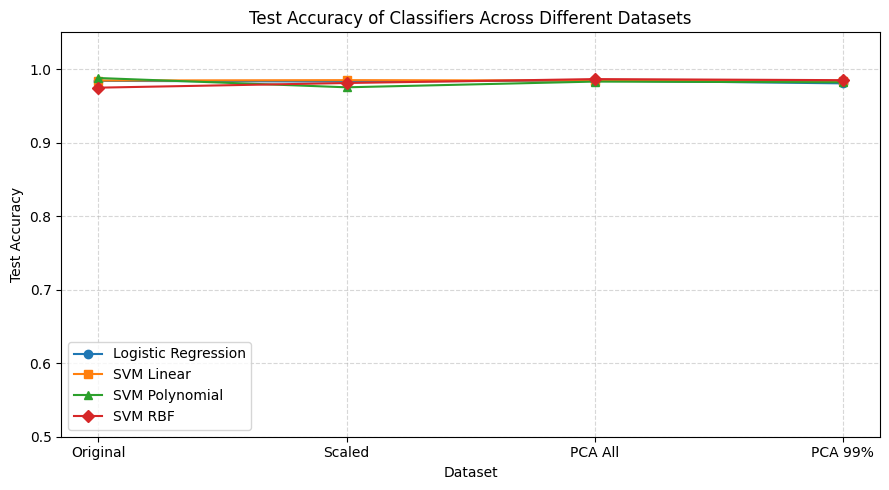

In [44]:
# line plot to see trends across datasets for each classifier
datasets   = ['Original', 'Scaled', 'PCA All', 'PCA 99%']
lr_vals    = [acc_lr_orig_test,   acc_lr_scaled_test,   acc_lr_pcaall_test,   acc_lr_pca99_test]
lin_vals   = [acc_lin_orig_test,  acc_lin_scaled_test,  acc_lin_pcaall_test,  acc_lin_pca99_test]
poly_vals  = [acc_poly_orig_test, acc_poly_scaled_test, acc_poly_pcaall_test, acc_poly_pca99_test]
rbf_vals   = [acc_rbf_orig_test,  acc_rbf_scaled_test,  acc_rbf_pcaall_test,  acc_rbf_pca99_test]

plt.figure(figsize=(9, 5))
plt.plot(datasets, lr_vals,   marker='o', label='Logistic Regression')
plt.plot(datasets, lin_vals,  marker='s', label='SVM Linear')
plt.plot(datasets, poly_vals, marker='^', label='SVM Polynomial')
plt.plot(datasets, rbf_vals,  marker='D', label='SVM RBF')

plt.title('Test Accuracy of Classifiers Across Different Datasets')
plt.ylabel('Test Accuracy')
plt.xlabel('Dataset')
plt.legend()
plt.ylim(0.5, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()